# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [1]:
# Task 0.1 — load config and verify env vars (token masked)
from config import get_settings

s = get_settings()
for key, value in s.items():
    shown = value[:8] + "..." if key == "token" else value
    print(f"{key:12} = {shown}")

host         = https://dbc-12b681c6-11a8.cloud.databricks.com
token        = dapi6cd3...
model        = databricks-meta-llama-3-3-70b-instruct
embeddings   = databricks-gte-large-en
vs_endpoint  = cs4603_rag_endpoint
vs_index     = cs4603.default.zakariya_analyst_index


In [2]:
# Task 0.3 — corpus ingestion (already executed once via `uv run python rag/ingest.py`).
# That script: uploaded PDF -> ai_parse_document -> ai_prep_search chunks table
# (cs4603.default.zakariya_analyst_chunks, 7 chunks, CDF enabled) -> TRIGGERED
# Delta Sync index cs4603.default.zakariya_analyst_index on cs4603_rag_endpoint.
# Here we just verify the index is READY and queryable:
from rag.ingest import verify

verify()

C:\Users\pc\Desktop\lums\Academics\Summer_26\Agentic_AI\cs4603-pa4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[NOTICE] Using a Personal Authentication Token (PAT). Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


Similarity search for 'What was the net revenue in fiscal year 2023?' returned 3 rows:
  chunk=6e466c4cc9a041679d12c7364dd84b88_1 source=annual_report.pdf page=2.0 score=0.5542141181737117
  chunk=6e466c4cc9a041679d12c7364dd84b88_0 source=annual_report.pdf page=1.0 score=0.5494051066173249
  chunk=6e466c4cc9a041679d12c7364dd84b88_2 source=annual_report.pdf page=4.0 score=0.5488568473865538


## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [3]:
# Task 1.7 — build the compiled graph (real LLM + Vector Search retriever + MCP tools)
from agent.graph import build_graph

graph = build_graph()
print("Graph compiled:", sorted(graph.get_graph().nodes))

Graph compiled: ['__end__', '__start__', 'mcp_tools', 'planner', 'rag_agent', 'supervisor', 'synthesizer']


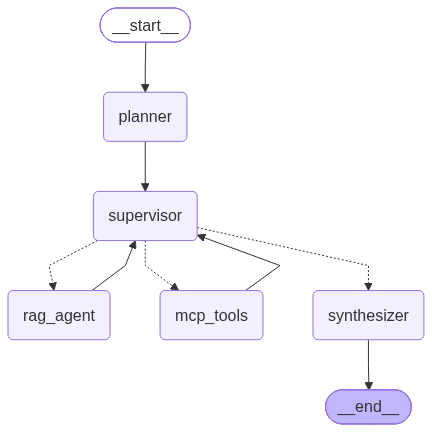

In [4]:
# Task 1.7 — visualize the compiled graph
try:
    from IPython.display import Image, display

    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:  # PNG rendering needs network (mermaid.ink); fall back to source
    print(f"(PNG rendering unavailable: {exc})\n")
    print(graph.get_graph().draw_mermaid())

### Test the graph


In [5]:
# Test 1 — retrieval-only query
local_answers = {}

def show(result):
    print("PLAN:")
    for step in result["plan"]:
        print(f"  - {step}")
    print("STEP RESULTS:")
    for r in result["step_results"]:
        print(f"  - {r}")
    print("\nFINAL ANSWER (messages[-1]):")
    print(result["messages"][-1].content)

Q_RAG = "What was the net income in 2023?"
result = graph.invoke({"messages": [{"role": "user", "content": Q_RAG}]})
local_answers[Q_RAG] = result["messages"][-1].content
show(result)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:
  - LOOK UP net income for fiscal year 2023
STEP RESULTS:
  - LOOK UP net income for fiscal year 2023 -> Net income for fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].

FINAL ANSWER (messages[-1]):
The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].


In [6]:
# Test 2 — computation-only query
Q_CALC = "What is 15% of 2.4 billion?"
result = graph.invoke({"messages": [{"role": "user", "content": Q_CALC}]})
local_answers[Q_CALC] = result["messages"][-1].content
show(result)

PLAN:
  - Calculate 15% of 2.4 billion
STEP RESULTS:
  - Calculate 15% of 2.4 billion -> 2.4 * 10**9 * 0.15 = 3.6e+08

FINAL ANSWER (messages[-1]):
To find 15% of 2.4 billion, we calculate 2.4 * 10^9 * 0.15. This results in 3.6e+08, which is equivalent to 360 million. Therefore, 15% of 2.4 billion is 360 million.


In [7]:
# Test 3 — combined query, with the full step-by-step execution trace.
# stream_mode=["updates", "values"] runs the graph ONCE: "updates" emits each
# node's state delta as it executes (the visible trace), while "values" carries
# the accumulated state so the last snapshot is the final result.
Q_COMBINED = "What was the revenue in 2023, and what would a 10% increase look like?"
combined = {"messages": [{"role": "user", "content": Q_COMBINED}]}

result = None
for mode, chunk in graph.stream(combined, stream_mode=["updates", "values"]):
    if mode == "values":
        result = chunk
        continue
    for node, delta in chunk.items():
        print(f"--- {node} ---")
        for key, value in (delta or {}).items():
            if key == "messages":
                value = [getattr(m, "content", m) for m in value]
            print(f"    {key}: {value}")

local_answers[Q_COMBINED] = result["messages"][-1].content
print()
show(result)

--- planner ---
    plan: ['LOOK UP revenue for fiscal year 2023', 'CALCULATE 10% increase using the revenue found in step 1']
    current_step_index: 0
    step_results: []


--- supervisor ---
    next_agent: rag_agent
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


--- rag_agent ---
    step_results: ['LOOK UP revenue for fiscal year 2023 -> The revenue for fiscal year 2023 was ¥16,910 billion (¥16.91 trillion) [source: annual_report.pdf, p.2].']
    current_step_index: 1


--- supervisor ---
    next_agent: mcp_tools


--- mcp_tools ---
    step_results: ['LOOK UP revenue for fiscal year 2023 -> The revenue for fiscal year 2023 was ¥16,910 billion (¥16.91 trillion) [source: annual_report.pdf, p.2].', 'CALCULATE 10% increase using the revenue found in step 1 -> 16910 * 1.10 = 18601']
    current_step_index: 2
--- supervisor ---
    next_agent: synthesizer


--- synthesizer ---
    final_answer: The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would be ¥16,910 billion * 1.10 = ¥18,601 billion, or approximately ¥18.60 trillion. This represents an increase of ¥1,691 billion from the original revenue.
    messages: ['The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would be ¥16,910 billion * 1.10 = ¥18,601 billion, or approximately ¥18.60 trillion. This represents an increase of ¥1,691 billion from the original revenue.']

PLAN:
  - LOOK UP revenue for fiscal year 2023
  - CALCULATE 10% increase using the revenue found in step 1
STEP RESULTS:
  - LOOK UP revenue for fiscal year 2023 -> The revenue for fiscal year 2023 was ¥16,910 billion (¥16.91 trillion) [source: annual_report.pdf, p.2].
  - CALCULATE 10% increase using the revenue found in step 1 -> 16910 * 1.10 = 18601

FINAL ANSWER (messages[-1]):
The revenue in 2023 was ¥16.91 trillion [source: annual_report.

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [8]:
!python -m pytest tests/test_smoke.py -q


.....                                                                    [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [9]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"



In [10]:
# Task 2.2 — the model was logged + registered by `uv run python deployment/deploy.py`
# (mlflow.langchain.log_model with code_paths=[agent, rag, tools, config.py] and
# pinned pip_requirements, registered in Unity Catalog). Show the registered versions:
import mlflow
from mlflow import MlflowClient

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")
UC_MODEL = "cs4603.default.zakariya_document_analyst"

client = MlflowClient()
for mv in client.search_model_versions(f"name='{UC_MODEL}'"):
    print(f"version {mv.version}  status={mv.status}  run_id={mv.run_id}")

version 4  status=READY  run_id=b077e41bf93e48b59820a28591ae7599
version 3  status=READY  run_id=5ae6ddc641c248d1bf5a2273cd3756b3
version 2  status=READY  run_id=120270115a73492fa8348b5eb8613584
version 1  status=READY  run_id=6f8e1564d73d481cb544edd1ae0c0f2a


In [11]:
# Task 2.3 — endpoint created by deploy.py (Small, scale_to_zero, secret refs).
# Confirm it is READY (same as `databricks serving-endpoints get zakariya-document-analyst`):
from databricks.sdk import WorkspaceClient

ENDPOINT = "zakariya-document-analyst"
w = WorkspaceClient()
ep = w.serving_endpoints.get(ENDPOINT)
entity = ep.config.served_entities[0]
print(f"endpoint:      {ep.name}")
print(f"state:         ready={ep.state.ready.value} config_update={ep.state.config_update.value}")
print(f"served entity: {entity.entity_name} v{entity.entity_version}")
print(f"workload:      {entity.workload_size}, scale_to_zero={entity.scale_to_zero_enabled}")
print("environment_vars (secrets stay references — never plaintext):")
for k, v in (entity.environment_vars or {}).items():
    print(f"  {k} = {v}")
print(f"\ninvocation URL: {s['host']}/serving-endpoints/{ENDPOINT}/invocations")

endpoint:      zakariya-document-analyst
state:         ready=READY config_update=NOT_UPDATING
served entity: cs4603.default.zakariya_document_analyst v4
workload:      Small, scale_to_zero=True
environment_vars (secrets stay references — never plaintext):
  DATABRICKS_HOST = {{secrets/cs4603-deploy/DATABRICKS_HOST}}
  DATABRICKS_MODEL = {{secrets/cs4603-deploy/DATABRICKS_MODEL}}
  DATABRICKS_TOKEN = {{secrets/cs4603-deploy/DATABRICKS_TOKEN}}
  MCP_CLIENT_ID = {{secrets/cs4603-deploy/MCP_CLIENT_ID}}
  MCP_CLIENT_SECRET = {{secrets/cs4603-deploy/MCP_CLIENT_SECRET}}
  EMBEDDINGS_ENDPOINT = databricks-gte-large-en
  MCP_SERVER_URL = https://cs4603-mcp-tools-7474646727822744.aws.databricksapps.com
  VECTOR_SEARCH_ENDPOINT = cs4603_rag_endpoint
  VECTOR_SEARCH_INDEX = cs4603.default.zakariya_analyst_index

invocation URL: https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations


### Test the deployed endpoint (Task 2.4)


In [12]:
# Task 2.4 (1) — call the endpoint with curl and show the RAW response.
# (subprocess so the notebook can inject the token from config, not hardcode it)
import json
import subprocess

URL = f"{s['host']}/serving-endpoints/{ENDPOINT}/invocations"
payload = json.dumps({"messages": [{"role": "user", "content": "What was the net income in 2023?"}]})
proc = subprocess.run(
    [
        "curl", "-s", "-w", "\nHTTP %{http_code}",
        "-H", f"Authorization: Bearer {s['token']}",
        "-H", "Content-Type: application/json",
        "-d", payload, URL,
    ],
    capture_output=True, text=True, timeout=300,
)
print(proc.stdout[:1500])

[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "e95a26cf-1c01-43cc-b31b-184410f91afd"}, {"content": "The net income in 2023 was \u00a51,107 billion [source: annual_report.pdf, p.2].", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "fa4fd203-0de2-4b34-9550-18c1c46a9063", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["LOOK UP net income for fiscal year 2023"], "current_step_index": 1, "step_results": ["LOOK UP net income for fiscal year 2023 -> Net income for fiscal year 2023 was \u00a51,107 billion [source: annual_report.pdf, p.2]."], "next_agent": "synthesizer", "final_answer": "The net income in 2023 was \u00a51,107 billion [source: annual_report.pdf, p.2]."}]
HTTP 200


In [13]:
# Task 2.4 (2-5) — parsed answers, the 3 test queries against the DEPLOYED endpoint,
# local vs deployed comparison, and latency per request.
#
# We logged with mlflow.langchain.log_model (Path A), so the endpoint returns RAW
# LangGraph state as a one-element batch list -> parse data[0]["messages"][-1]["content"].
# (The OpenAI SDK's resp.choices[...] would fail on this shape by design — see README Task 2.4.)
import time

import requests


def ask_deployed(question: str) -> tuple[str, float]:
    t0 = time.perf_counter()
    r = requests.post(
        URL,
        headers={"Authorization": f"Bearer {s['token']}"},
        json={"messages": [{"role": "user", "content": question}]},
        timeout=300,
    )
    elapsed = time.perf_counter() - t0
    r.raise_for_status()
    return r.json()[0]["messages"][-1]["content"], elapsed


latencies = {}
for q in [Q_RAG, Q_CALC, Q_COMBINED]:
    answer, dt = ask_deployed(q)
    latencies[q] = dt
    print(f"Q: {q}   [{dt:.1f}s]")
    print(f"  deployed: {answer}")
    print(f"  local:    {local_answers[q]}")
    print()

# Latency: first-request-after-idle vs immediately repeated (warm) request.
warm_answer, warm_dt = ask_deployed(Q_RAG)
print(f"repeat of retrieval query (warm): {warm_dt:.1f}s (first ask above: {latencies[Q_RAG]:.1f}s)")
print(
    "\nNote: with scale_to_zero the FIRST request after the endpoint sleeps pays a"
    "\ncold start of several MINUTES (container boot + model load). The timings here"
    "\nare warm-container timings; per-request latency is dominated by the 4-7"
    "\nsequential LLM calls the graph makes, so local and deployed times are similar."
)

Q: What was the net income in 2023?   [5.6s]
  deployed: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].
  local:    The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].



Q: What is 15% of 2.4 billion?   [5.0s]
  deployed: To find 15% of 2.4 billion, we calculate 2.4 * 10^9 * 0.15. This results in 3.6e+08, which is equivalent to 360 million. Therefore, 15% of 2.4 billion is 360 million.
  local:    To find 15% of 2.4 billion, we calculate 2.4 * 10^9 * 0.15. This results in 3.6e+08, which is equivalent to 360 million. Therefore, 15% of 2.4 billion is 360 million.



Q: What was the revenue in 2023, and what would a 10% increase look like?   [7.1s]
  deployed: The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would be ¥16,910 billion * 1.10 = ¥18,601 billion, or approximately ¥18.60 trillion.
  local:    The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2]. A 10% increase would be ¥16,910 billion * 1.10 = ¥18,601 billion, or approximately ¥18.60 trillion. This represents an increase of ¥1,691 billion from the original revenue.



repeat of retrieval query (warm): 5.7s (first ask above: 5.6s)

Note: with scale_to_zero the FIRST request after the endpoint sleeps pays a
cold start of several MINUTES (container boot + model load). The timings here
are warm-container timings; per-request latency is dominated by the 4-7
sequential LLM calls the graph makes, so local and deployed times are similar.


## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [14]:
# Task 3.2 (1-3) — instantiate the client, health-check, ask.
from client.sdk import AnalystClientError, DocumentAnalystClient

c = DocumentAnalystClient(ENDPOINT)  # host/token read from env (.env)
ok = c.health_check()
print("health_check():", ok)
assert ok is True

answer = c.ask("What was the net income in 2023?")
print("ask():", answer)

health_check(): True


ask(): The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2].


In [15]:
# Task 3.2 (4) — ask_streaming(): chunks printed as they arrive.
# This models-from-code endpoint rejects `stream: true` (no predict_stream),
# so per the Task 3.1 caveat the client falls back to yielding the complete
# answer as ONE chunk — a valid, documented outcome.
import logging

logging.basicConfig(level=logging.INFO)
for i, chunk in enumerate(c.ask_streaming("Summarize FY2023 revenue.")):
    print(f"[chunk {i}] {chunk}")

INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 400 Bad Request"


INFO:client.sdk:Endpoint rejects streaming; yielding full answer once


INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 200 OK"


[chunk 0] The revenue for FY2023 was ¥16,910 billion (¥16.91 trillion) [source: annual_report.pdf, p.2].


In [16]:
# Task 3.2 (5) — simulate a timeout: with timeout=0.001 the request cannot
# complete, and the client raises TimeoutError with the elapsed time.
try:
    DocumentAnalystClient(ENDPOINT, timeout=0.001).ask("What was the net income?")
except TimeoutError as exc:
    print("TimeoutError:", exc)

# Task 3.2 (6) — simulate the endpoint being unavailable (503, e.g. while
# scaling from zero) to show the retry behaviour. Instead of hammering the real
# endpoint, we inject an httpx.MockTransport that answers 503 twice and then
# succeeds — watch the client back off 1s, then 2s, then recover.

import httpx

fake_state = {"calls": 0}
fake_body = [{"messages": [{"role": "assistant", "content": "recovered after retries"}]}]


def flaky_endpoint(request: httpx.Request) -> httpx.Response:
    fake_state["calls"] += 1
    if fake_state["calls"] <= 2:
        return httpx.Response(503, json={"message": "endpoint is scaling up"})
    return httpx.Response(200, json=fake_body)


flaky = DocumentAnalystClient(ENDPOINT)
flaky._client = httpx.Client(transport=httpx.MockTransport(flaky_endpoint))

t0 = time.perf_counter()
print("ask() against flaky endpoint:", flaky.ask("test"))
print(f"total attempts: {fake_state['calls']} (2 x 503 + 1 success), "
      f"elapsed {time.perf_counter() - t0:.1f}s (backoff 1s + 2s)")

# And when retries are exhausted, the client raises AnalystClientError:
always_down = DocumentAnalystClient(ENDPOINT, max_retries=1)
always_down._client = httpx.Client(
    transport=httpx.MockTransport(lambda r: httpx.Response(503, json={"message": "still scaling"}))
)
try:
    always_down.ask("test")
except AnalystClientError as exc:
    print("after retries exhausted ->", exc)

TimeoutError: Request to zakariya-document-analyst timed out after 0.01s (timeout=0.001s)


INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 503 Service Unavailable"


INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 503 Service Unavailable"


INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 503 Service Unavailable"


ask() against flaky endpoint: recovered after retries
total attempts: 3 (2 x 503 + 1 success), elapsed 3.0s (backoff 1s + 2s)


INFO:httpx:HTTP Request: POST https://dbc-12b681c6-11a8.cloud.databricks.com/serving-endpoints/zakariya-document-analyst/invocations "HTTP/1.1 503 Service Unavailable"


after retries exhausted -> [status=503 request_id=None] Endpoint 'zakariya-document-analyst' returned HTTP 503: still scaling


## Bonus C — Standalone MCP server (Databricks App)

`tools/mcp_server.py` is deployed as its **own** Databricks App (`cs4603-mcp-tools`) serving the same
five tools over **streamable-http**. The serving endpoint's environment carries `MCP_SERVER_URL` plus a
service-principal client id/secret (secret refs) that `agent/graph.py` uses to mint the **OAuth** token
Databricks Apps ingress requires (PATs are rejected with 401). Tool traffic now goes
`serving container ── HTTPS + bearer ──▶ MCP app`; the stdio subprocess is only a fallback.

The proof below: calc works while the app is RUNNING → **stop** the app → the calculation step
fails visibly → **start** it again → recovery.

In [17]:
# Bonus C (1-2) — the app is a separate Databricks App in RUNNING state, and the
# serving endpoint's env now routes tool traffic to it (v4 config).
APP_NAME = "cs4603-mcp-tools"

app = w.apps.get(APP_NAME)
print(f"app: {app.name}")
print(f"  url:     {app.url}")
print(f"  compute: {app.compute_status.state.value}")
print(f"  status:  {app.app_status.state.value} — {app.app_status.message}")

ep = w.serving_endpoints.get(ENDPOINT)
entity = ep.config.served_entities[0]
print(f"\nendpoint {ep.name}: v{entity.entity_version}, MCP env:")
for k, v in sorted((entity.environment_vars or {}).items()):
    if k.startswith("MCP_"):
        print(f"  {k} = {v}")

app: cs4603-mcp-tools
  url:     https://cs4603-mcp-tools-7474646727822744.aws.databricksapps.com
  compute: ACTIVE
  status:  RUNNING — App has status: App is running



endpoint zakariya-document-analyst: v4, MCP env:
  MCP_CLIENT_ID = {{secrets/cs4603-deploy/MCP_CLIENT_ID}}
  MCP_CLIENT_SECRET = {{secrets/cs4603-deploy/MCP_CLIENT_SECRET}}
  MCP_SERVER_URL = https://cs4603-mcp-tools-7474646727822744.aws.databricksapps.com


In [18]:
# Bonus C (3) — calculation via the REMOTE MCP server (app RUNNING).
def deployed_calc_steps(question: str):
    r = requests.post(
        URL,
        headers={"Authorization": f"Bearer {s['token']}"},
        json={"messages": [{"role": "user", "content": question}]},
        timeout=300,
    )
    r.raise_for_status()
    state = r.json()[0]
    return state["step_results"], state["messages"][-1]["content"]

steps, answer = deployed_calc_steps("What is 12% of 950 million?")
print("step_results:", steps)
print("answer:", answer)

step_results: ['Calculate 12% of 950 million -> 0.12 * 950 = 114']
answer: 12% of 950 million is 114 million.


In [19]:
# Bonus C (4) — decoupling proof: STOP the app -> the deployed calculation step
# fails (the tool traffic really does go over HTTP); START it -> recovery.
# If the model were still using its bundled stdio server, stopping the app
# would change nothing — this is the definitive test.
w.apps.stop(APP_NAME)
print("app stopped:", w.apps.get(APP_NAME).compute_status.state.value)

steps, answer = deployed_calc_steps("What is 12% of 950 million?")
print("\nwith app STOPPED:")
print("  step_results:", steps)
print("  answer:", answer[:200])

print("\nrestarting app ...")
w.apps.start(APP_NAME)
for _ in range(30):
    app = w.apps.get(APP_NAME)
    if (
        app.compute_status.state.value == "ACTIVE"
        and app.app_status.state.value == "RUNNING"
    ):
        break
    time.sleep(15)
print("app:", app.compute_status.state.value, "/", app.app_status.state.value)

steps, answer = deployed_calc_steps("What is 12% of 950 million?")
print("\nafter restart:")
print("  step_results:", steps)

app stopped: STOPPING



with app STOPPED:
  step_results: ["Calculate 12% of 950 million -> error: tool call 'calculate' failed (ExceptionGroup: unhandled errors in a TaskGroup (1 sub-exception))"]
  answer: Unfortunately, the calculation of 12% of 950 million could not be verified from the report as the tool call 'calculate' failed [source: step result, p.1]. Therefore, I cannot provide the answer to thi

restarting app ...


app: ACTIVE / RUNNING



after restart:
  step_results: ['Calculate 12% of 950 million -> 0.12 * 950 = 114']


## Bonus B — Deployment via the `databricks-agents` SDK

`deployment/deploy_agents.py` reuses the whole manual pipeline but (1) wraps the same graph in a
`mlflow.pyfunc.ChatAgent` (`deployment/agent_model_chat.py`) because `agents.deploy()` rejects the
raw-LangGraph-state schema, and (2) replaces the manual `WorkspaceClient` endpoint step with ONE
`agents.deploy(...)` call that auto-provisions the serving endpoint **and** a Review App.
Three queries were submitted through the Review App with feedback ratings (retrieval, calculation,
combined); the feedback lands as trace assessments in the `pa4-document-analyst` MLflow experiment.

In [ ]:
# Bonus B (1) — the agents.deploy() deployment and a live query.
# NOTE: a ChatAgent endpoint returns the ChatAgent schema {messages, id} —
# chat-shaped (unlike Part 2's raw state), parsed via messages[-1].
from databricks import agents

AGENTS_MODEL = "cs4603.default.zakariya_document_analyst_chat"
dep = agents.get_deployments(model_name=AGENTS_MODEL)[0]
print("endpoint:  ", dep.endpoint_name)
print("model:     ", dep.model_name, "v" + str(dep.model_version))
print("review app:", dep.review_app_url)

r = requests.post(
    f"{s['host']}/serving-endpoints/{dep.endpoint_name}/invocations",
    headers={"Authorization": f"Bearer {s['token']}"},
    json={"messages": [{"role": "user", "content": "What was the operating profit in 2023, and what would it be after 5% growth?"}]},
    timeout=300,
)
print("\nHTTP", r.status_code, "->", r.json()["messages"][-1]["content"][:250])

In [ ]:
# Bonus B (2-3) — Review App feedback shown in the MLflow experiment.
# The Review App is bound to the pa4-document-analyst experiment; every chat
# turn becomes a trace and each rating an assessment attached to it.
from databricks.agents.review_app import get_review_app

EXP_ID = "2887666556312014"  # /Users/27100222@lums.edu.pk/pa4-document-analyst
ra = get_review_app(experiment_id=EXP_ID)
print("review app:", ra.review_app_id, "-> experiment", ra.experiment_id)

traces = mlflow.search_traces(experiment_ids=[EXP_ID], max_results=50, return_type="list")
print(f"traces in experiment: {len(traces)}\n")
for t in traces:
    info = t.info
    assessments = list(getattr(info, "assessments", []) or [])
    preview = (getattr(info, "request_preview", "") or "").replace("\n", " ")[:80]
    print(f"- {info.trace_id[:32]}...  {preview}")
    for a in assessments:
        fb = getattr(a, "feedback", None)
        value = fb.value if fb is not None else getattr(a, "value", None)
        rationale = getattr(a, "rationale", None)
        print(f"    feedback: {a.name} = {value}" + (f"  ({rationale})" if rationale else ""))